# The problem
We want to solve for time-dependent block motions, applied CMI displacements, and slip/slip deficit, throughout the earthquake cycle.  The time-dependent quantities (or the weights of functions parameterizing them) are stored in a state vector $\mathbf{x}(t)$, and we assume that there is a linear relationship between the state vector and observables $\mathbf{b}(t)$ at all time steps.  We further assume that we have prior constraints on state vector elements both at each time step and across time steps.  At each time step we assume that coupling is bounded in the range $-10^6\leq c\leq 1$ and we seek a solution that varies smoothly in time with the exception of the days on which earthquakes occur. The general problem definition is to minimize a loss, $J$,


$$   J = \sum_{t=0}^{T-1}||\mathbf{A}\mathbf{x}(t) - \mathbf{b}(t)||^2 + \lambda \sum_{t=1}^{T-1}||\mathbf{x}(t) -\mathbf{x}(t-1)||^2$$

across time intervals between coseismic events subject to a coupling  constraint at all time steps,

$$ f(\mathbf{A},\mathbf{x}(t)) \leq c $$

The constraint function $f(\mathbf{A},\mathbf{x}(t))$ counts the number of fault mesh elements that do not satisfy the coupling constraints.  Note that this is discrete but can be treated as continuous with linear interpolation or similar.

This optimization problem can be solved with SLSQP (Dieter Kraft, A software package for Sequential Quadratic programming) as implemented in \texttt{scipy.optimize.minimize}.  Note that while this approach requires an initial guess of the state at each time step, updates to the state at each time step, in the course of minimizing $J$, do not require a solution to the linear system, instead only a check of whether or not the constraints are satisfied by a proposed $\mathbf{x}(t)$.

### For this example I just do a non-negative constraint

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%config InlineBackend.figure_format = "retina"

# Constants and common functions

In [2]:
T = 100
obs_dim = 50
state_dim = 3
# lambda_reg = np.array([1.5, 1.5, 1.5])
lambda_reg = np.array([5.0, 5.0, 5.0])

c_pos = -1e-6  # Weird positivity hack


def objective(x_vec, b, A, lambda_reg):
    """
    J = sum_{t=0}^{T-1} ||A x(t) - b(t)||^2 + sum_{t=1}^{T-1} sum_{i=1}^{state_dim} lambda_reg[i] (x_i(t) - x_i(t-1))^2
    """
    T = b.shape[0]
    state_dim = A.shape[1]
    x = x_vec.reshape((T, state_dim))
    data_term = np.sum((A @ x.T - b.T) ** 2)
    smooth_term = np.sum(lambda_reg * (x[1:] - x[:-1]) ** 2)
    return data_term + smooth_term


def constraint_func(x_vec, b, A, c_pos):
    """
    Enforce the positivity constraint at each time step:
       c_pos - f(x(t)) >= 0, with f(x(t)) = -min(x(t)).
    Equivalently, min(x(t)) >= -c_pos.
    """
    T = b.shape[0]
    state_dim = A.shape[1]
    x = x_vec.reshape((T, state_dim))
    return np.array([c_pos + np.min(x[t]) for t in range(T)])

# Forward model

In [3]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)


def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
t_vec = np.copy(t)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

b_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
b_noise = b_true + noise_scale * np.random.normal(size=b_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

b_true_noco = np.copy(b_true)
b_noise_noco = np.copy(b_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = b_true_noco[i, coseismic_idx] - b_true_noco[i, coseismic_idx - 1]
    b_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = b_noise_noco[i, coseismic_idx] - b_noise_noco[i, coseismic_idx - 1]
    b_noise_noco[i, coseismic_idx::] -= coseismic_step

b = np.copy(b_noise_noco.T)

# Two batch state estimation

In [4]:
t_max = 100
t_vec = np.linspace(0, 1, t_max)
smoothing_weights = np.array([5e1, 2e0, 2e1])
n_state = 3

# First batch before earthquake
x_initial = np.array([0.0, 0.0, 0.0])
start_idx = 0
end_idx = coseismic_idx + 1
x0_guess = np.zeros((end_idx - start_idx, state_dim))
A_pinv = np.linalg.pinv(A)
for i in range(start_idx, end_idx):
    x0_guess[i] = A_pinv.dot(b[i])
x0_vec = x0_guess.flatten()

constraints = [
    {
        "type": "ineq",
        "fun": lambda x: constraint_func(x, b[start_idx:end_idx], A, c_pos),
    },
    {
        "type": "eq",
        "fun": lambda x: x.reshape((end_idx - start_idx, state_dim))[0] - x_initial,
    },
]

result = minimize(
    objective,
    x0_vec,
    args=(b[start_idx:end_idx, :], A, lambda_reg),
    method="SLSQP",
    constraints=constraints,
    options={"maxiter": 500, "ftol": 1e-9},
)
x_est = result.x.reshape((end_idx - start_idx, state_dim))

# Second batch after earthquake
start_idx = coseismic_idx
end_idx = 100
x0_guess = np.zeros((end_idx - start_idx, state_dim))
A_pinv = np.linalg.pinv(A)
for i in range(start_idx, end_idx):
    x0_guess[i - start_idx] = A_pinv.dot(b[i])
x0_vec = x0_guess.flatten()
x_initial = x_est[-1, :]

constraints = [
    {
        "type": "ineq",
        "fun": lambda x: constraint_func(x, b[start_idx:end_idx], A, c_pos),
    },
    {
        "type": "eq",
        "fun": lambda x: x.reshape((end_idx - start_idx, state_dim))[0] - x_initial,
    },
]

result = minimize(
    objective,
    x0_vec,
    args=(b[start_idx:end_idx, :], A, lambda_reg),
    method="SLSQP",
    constraints=constraints,
    options={"maxiter": 500, "ftol": 1e-9},
)

x_est_post = result.x.reshape((end_idx - start_idx, state_dim))

# Plot data, state estimates, and state velocity

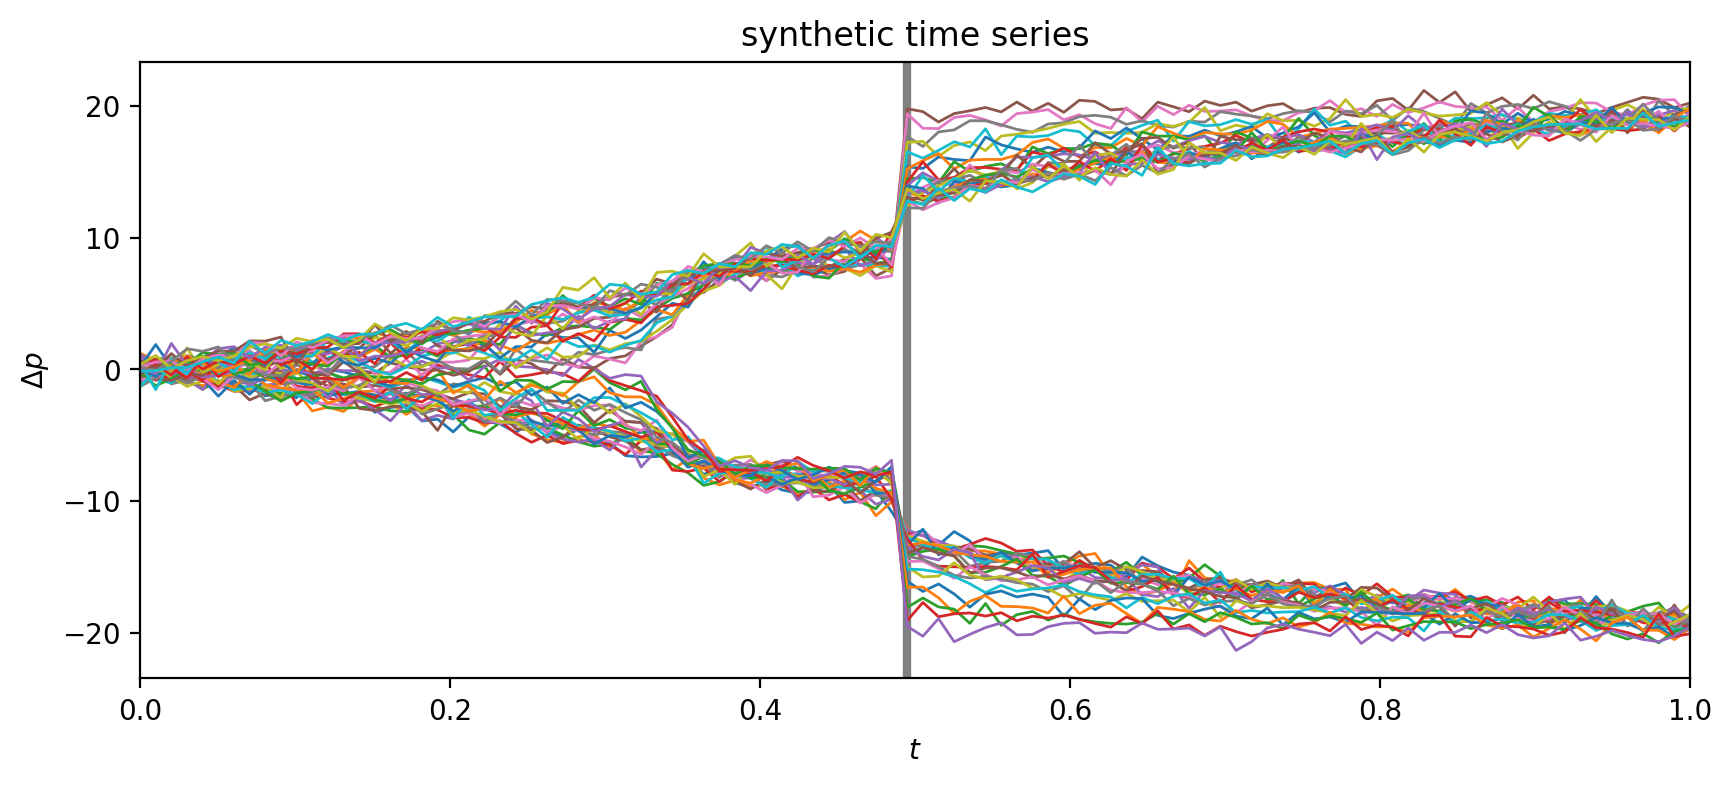

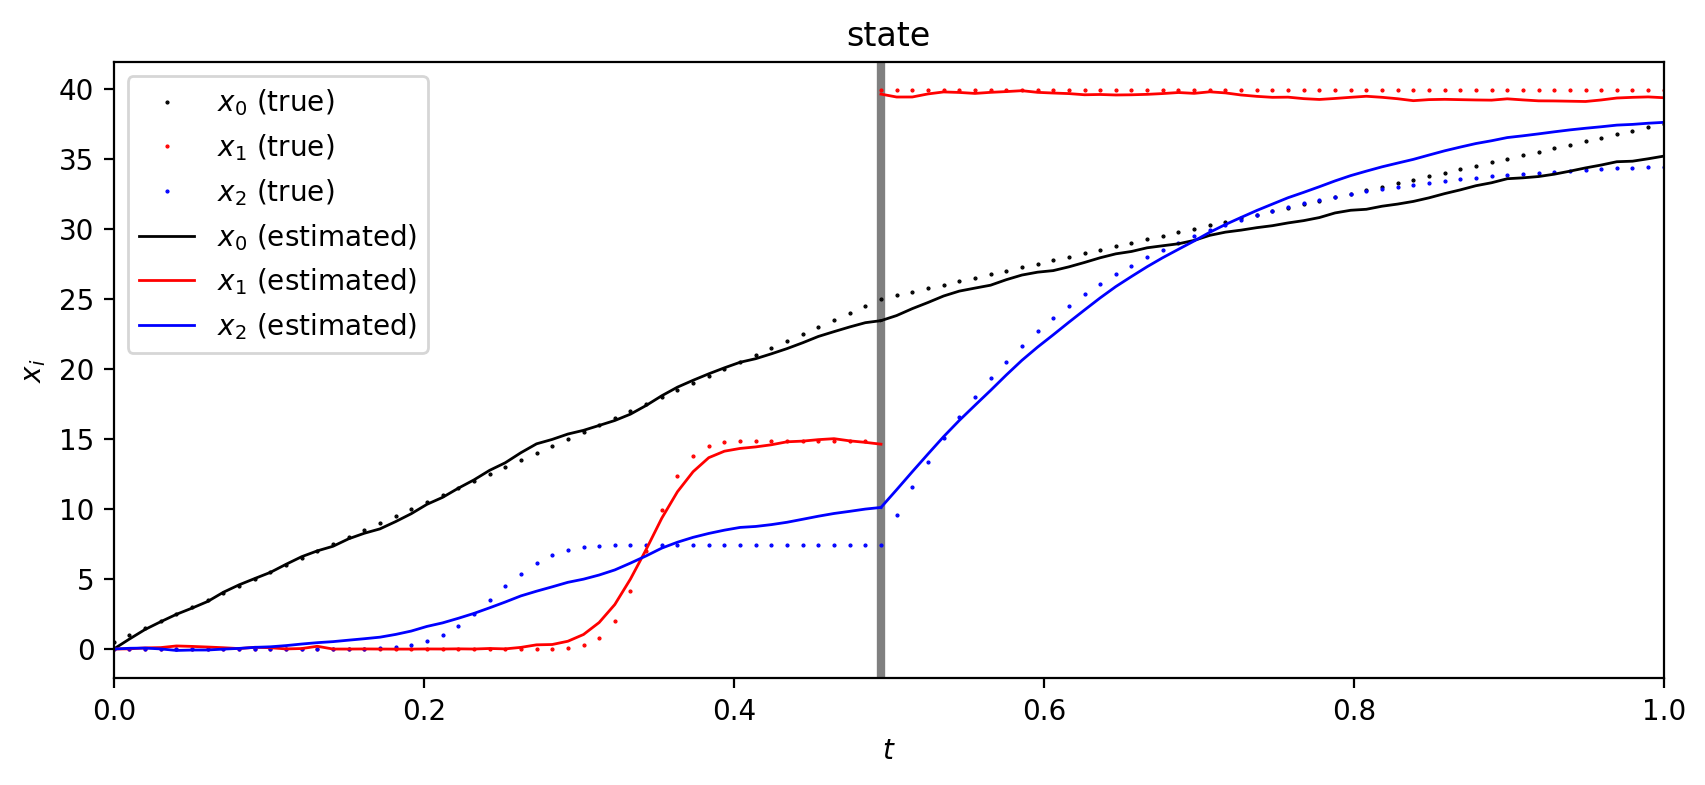

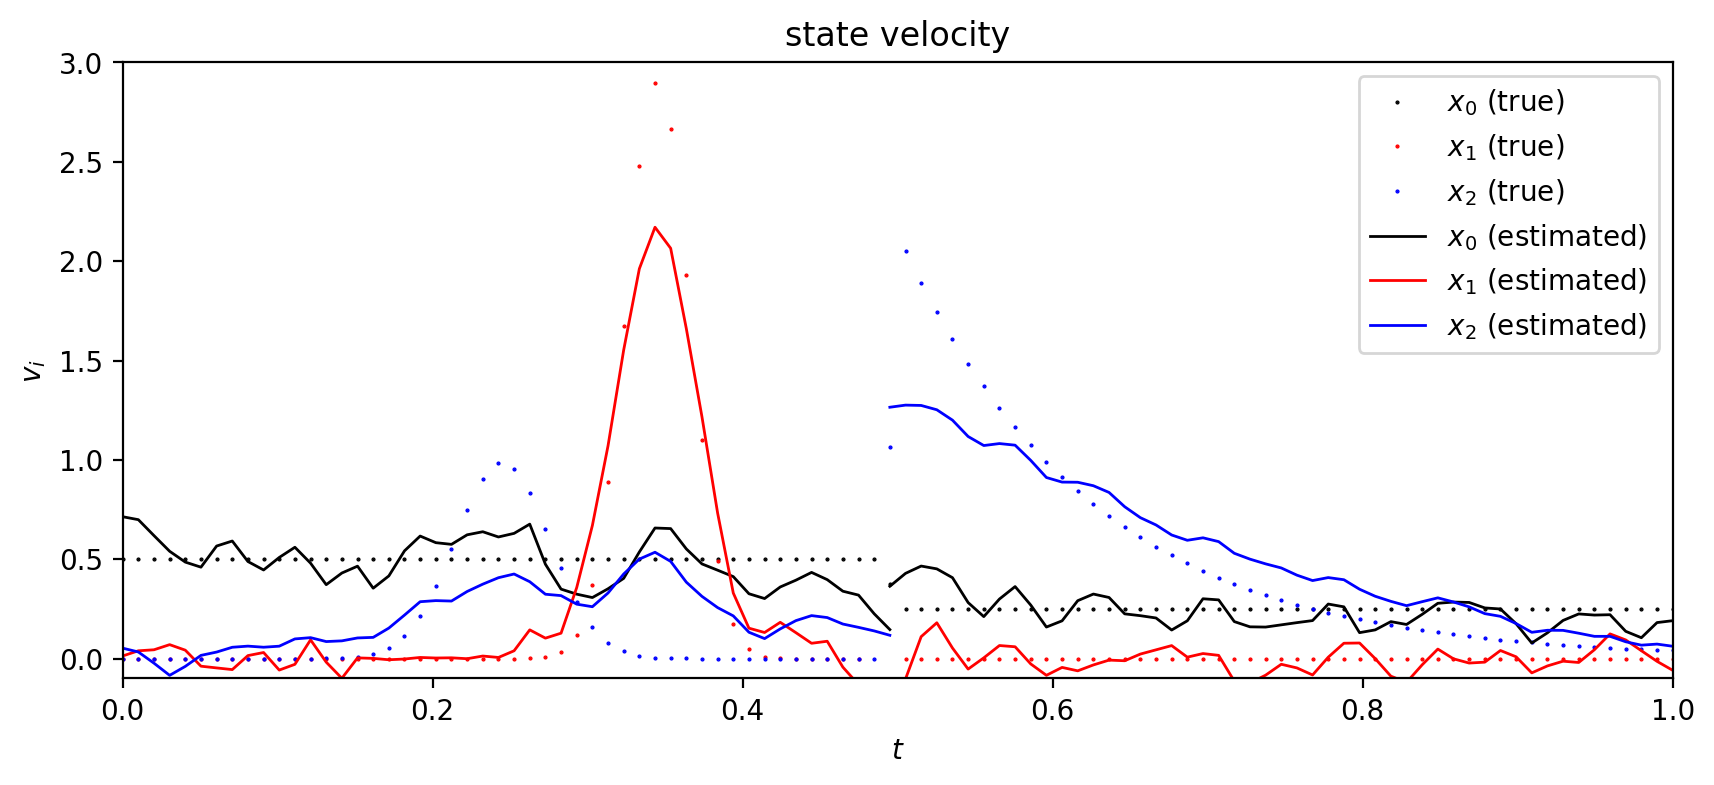

In [5]:
LINEWIDTH = 1.0

# Plot observed time series
plt.figure(figsize=(10, 4))
plt.axvline(x=t_vec[coseismic_idx], color="gray", linestyle="-", linewidth=3)
for i in range(50):
    plt.plot(
        t_vec,
        100 * b_noise[i, :],
        "-",
        linewidth=LINEWIDTH,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
plt.title("synthetic time series")
plt.show()

# Plot true and and estimated state
plt.figure(figsize=(10, 4))
plt.axvline(x=t_vec[coseismic_idx], color="gray", linestyle="-", linewidth=3)

# Plot true state
plt.plot(t_vec, x0, ".k", label="$x_0$ (true)", linewidth=LINEWIDTH, markersize=1.0)
plt.plot(t_vec, x1, ".r", label="$x_1$ (true)", linewidth=LINEWIDTH, markersize=1.0)
plt.plot(t_vec, x2, ".b", label="$x_2$ (true)", linewidth=LINEWIDTH, markersize=1.0)

# Plot first batch
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 0] / dt,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 1] / dt,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 2] / dt,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=LINEWIDTH,
)

# Plot second batch
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 0] / dt, "-k", linewidth=LINEWIDTH)
plt.plot(
    t_vec[coseismic_idx::],
    x_est_post[:, 1] / dt + np.max(np.diff(x1)),
    "-r",
    linewidth=LINEWIDTH,
)
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 2] / dt, "-b", linewidth=LINEWIDTH)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state")
plt.show()

plt.figure(figsize=(10, 4))

# Plot true state
plt.plot(
    t_vec,
    np.gradient(x0),
    ".k",
    label="$x_0$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x1),
    ".r",
    label="$x_1$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)
plt.plot(
    t_vec,
    np.gradient(x2),
    ".b",
    label="$x_2$ (true)",
    linewidth=LINEWIDTH,
    markersize=1.0,
)

# Plot first batch
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 0] / dt),
    "-k",
    label="$x_0$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 1] / dt),
    "-r",
    label="$x_1$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    np.gradient(x_est[:, 2] / dt),
    "-b",
    label="$x_2$ (estimated)",
    linewidth=LINEWIDTH,
)

# Plot second batch
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 0] / dt),
    "-k",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 1] / dt + np.max(np.diff(x1))),
    "-r",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[coseismic_idx::],
    np.gradient(x_est_post[:, 2] / dt),
    "-b",
    linewidth=LINEWIDTH,
)

plt.xlabel("$t$")
plt.ylabel("$v_i$")
plt.xlim([0, 1])
plt.ylim([-0.1, 3])
plt.legend()
plt.title("state velocity")
plt.show()

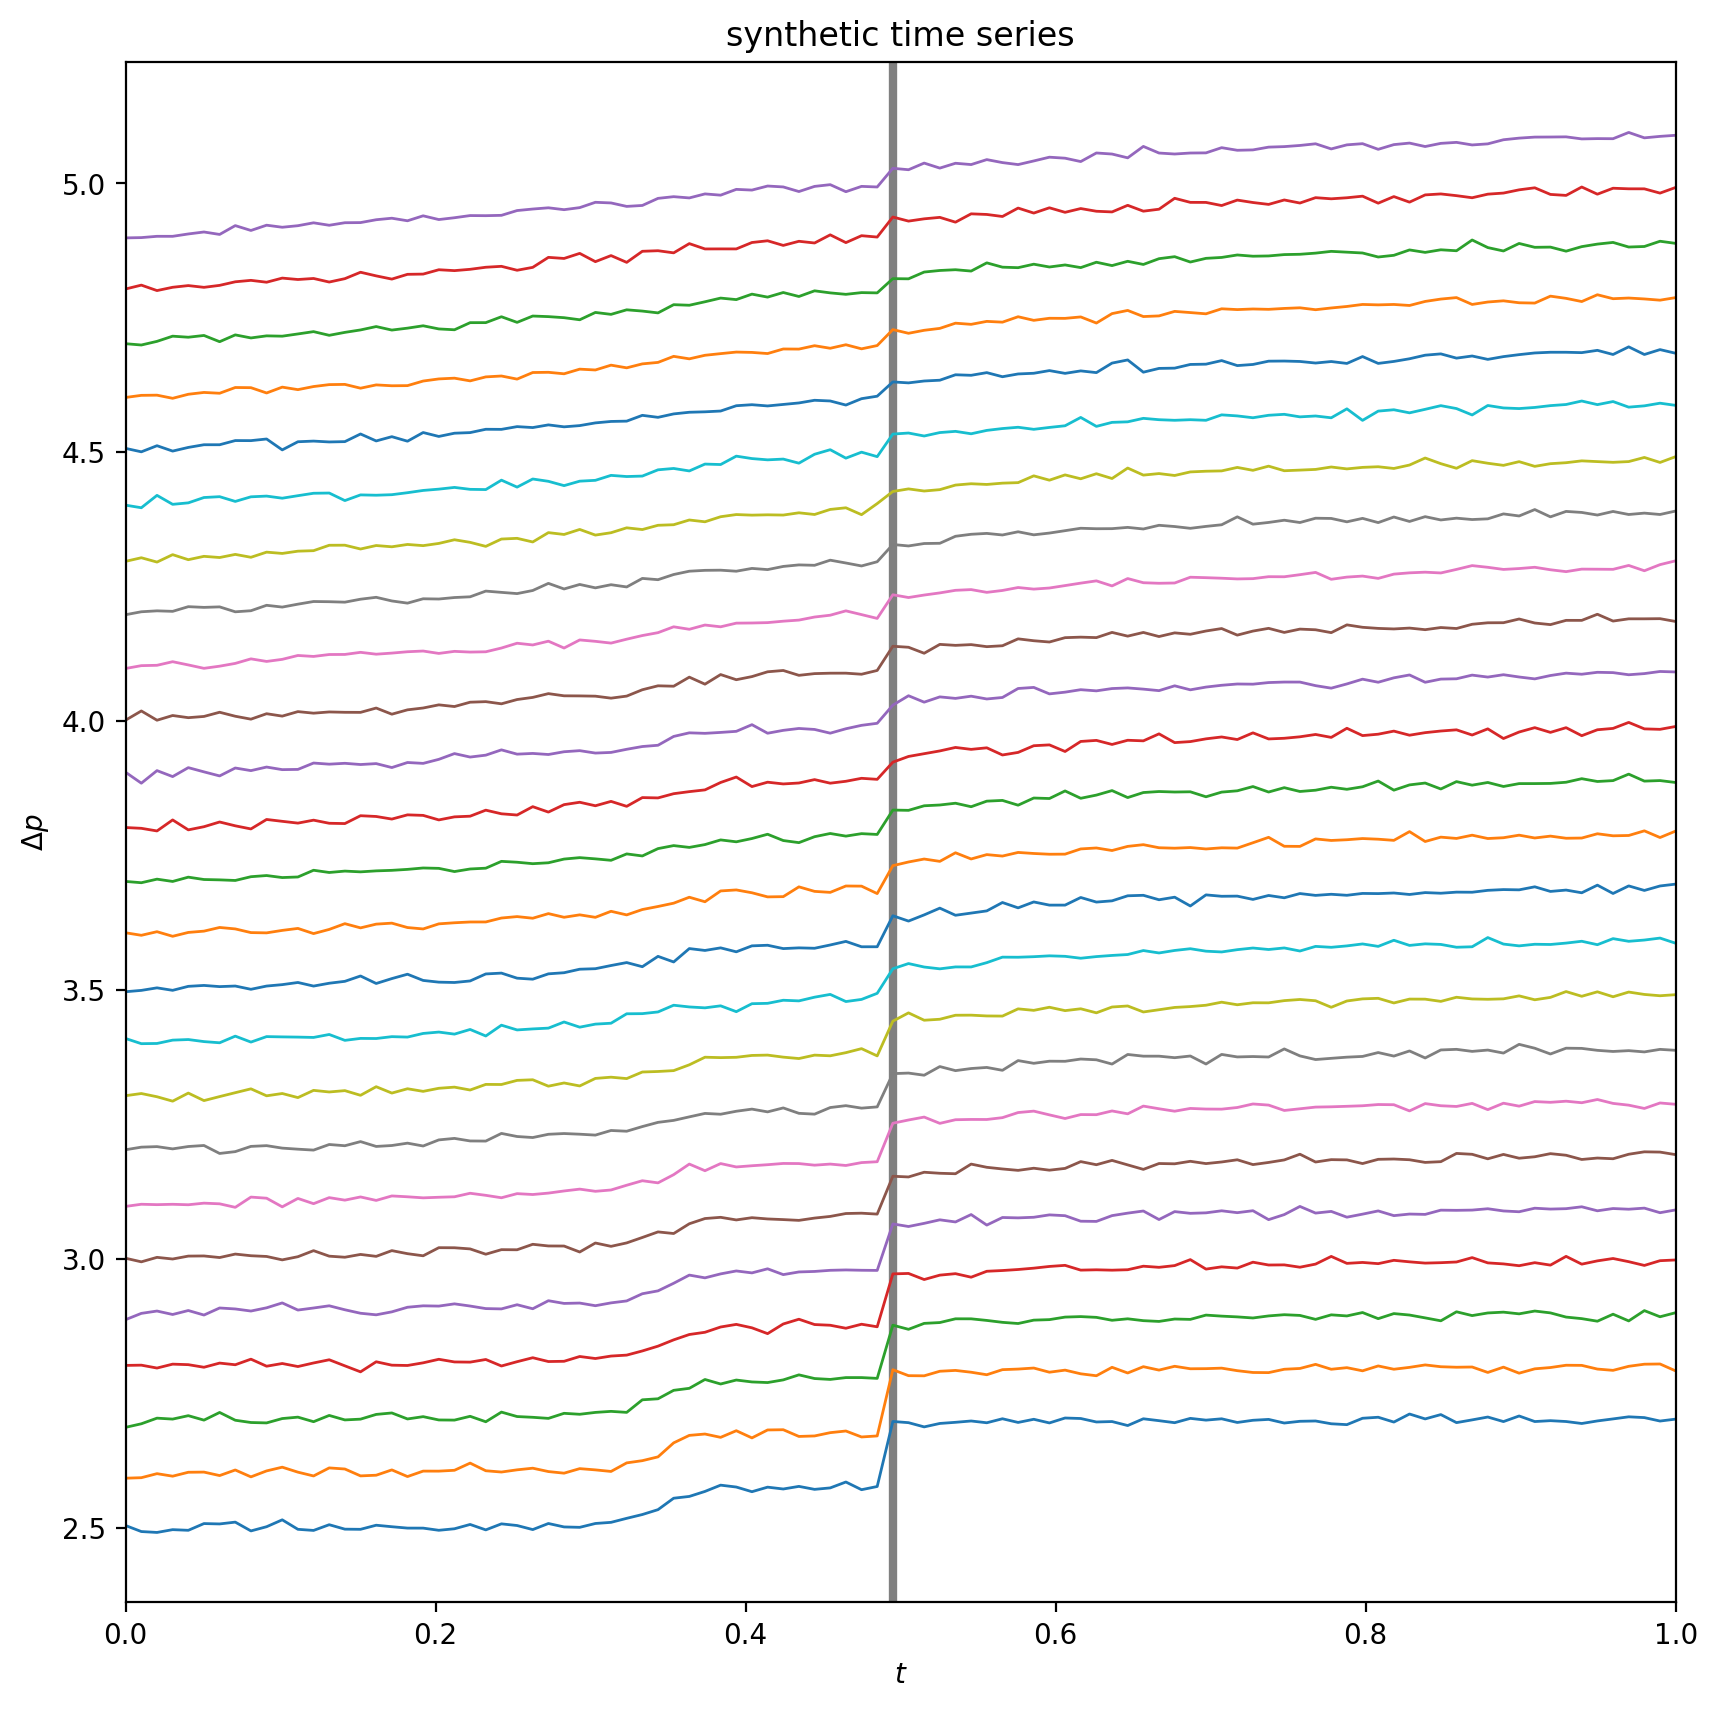

In [ ]:
# Plot observed time series
plt.figure(figsize=(10, 10))
plt.axvline(x=t_vec[coseismic_idx], color="gray", linestyle="-", linewidth=3)
for i in range(25, 50):
    plt.plot(t_vec, b_noise[i, :] + 0.10 * i, "-", linewidth=1, markersize=1.0)
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
plt.title("synthetic time series")
plt.show()